# NYC Airbnb Pricing and Demand Analysis Dashboard
**Goal**: Analyze listing prices, supply, future availability, and review activity to support Airbnb pricing and homepage recommendation decisions.

**Dataset**: AB_NYC_2019.csv (48,895 listings; historical 2019 snapshot)

**Research question**: How do listing prices, supply, and review activity vary across NYC boroughs, room types, and neighbourhoods?

## Step 0: Environment Setup & Data Loading

In [1]:
#import pip, remove # if pip packages are not correctly imported
#!pip install pandas
#!pip install seaborn
#pip install matplotlib
#!pip install --upgrade pip


In [2]:
from matplotlib.pyplot import viridis
#Import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load data
df = pd.read_csv('AB_NYC_2019.csv')
print(df.shape)
df.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
# Data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## Step 1: Data Cleaning

### 1.1 Check Missing Values

In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### 1.2 Fill Missing Values

Missing values in **name** or **host_name** only have limited effect to the overall analysis. The main missing-value issues are in **last_review** and **reviews_per_month**.

In [6]:
df['last_review'] = df['last_review'].fillna('NaT')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = pd.to_datetime(df['last_review'])
df.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

### 1.3 Handle Outliers


In this step, we'll handle extreme outliers found in **price, minimum_nights, and availability_365**

In [7]:
df[['price', 'minimum_nights', 'availability_365']].describe()

,price,minimum_nights,availability_365
count,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,112.781327
std,240.154170,20.510550,131.622289
min,0.000000,1.000000,0.000000
25%,69.000000,1.000000,0.000000
50%,106.000000,3.000000,45.000000
75%,175.000000,5.000000,227.000000
max,10000.000000,1250.000000,365.000000


In [8]:
(df['price'] == 0).sum()

np.int64(11)

In [9]:
(df['minimum_nights'] > 365).sum()

np.int64(14)

In [10]:
(df['price'] >= 5000).sum()

np.int64(26)

For data cleaning, I remove rows where **price = 0** or **minimum_nights > 365** because they are not useful for realistic pricing analysis.

In [11]:
original_size = df.shape[0]
print(f'Before cleaning: {original_size} rows')# first record the original data

# remove outliers
df = df[df['price'] > 0]
df = df[df['minimum_nights'] <= 365]
#after cleaning
print(f'After cleaning: {df.shape[0]} rows')

Before cleaning: 48895 rows
After cleaning: 48870 rows


This cleaning step removes 25 rows related to unrealistic **price** or **minimum_nights** values.

### 1.4 Duplicate Check


In [12]:
duplicates = df['id'].duplicated().sum()
print(f'duplicate: {duplicates}')
full_duplicate = df.duplicated().sum()
print(f'full duplicated rows: {full_duplicate}')


duplicate: 0
full duplicated rows: 0


There are no duplicated listing IDs, so the dataset does not require duplicate removal.

### 1.5 Add Helper Columns and Document Metric Limitations

Originally, I considered estimating annual income with:

`estimated_income = price * (365 - availability_365)`

The logic was that `availability_365` records the number of days available in the next 365 days, so `365 - availability_365` might approximate booked nights. However, this is not reliable enough for a final profit analysis. According to Inside Airbnb, availability data comes from the public future availability calendar, not confirmed historical booking records. Airbnb calendar dates can also be blocked for reasons other than guest bookings, such as host availability settings, preparation time, synced calendars, pending requests, or platform restrictions.

Even if unavailable nights were actual booked nights, `price * booked nights` would still represent estimated gross revenue, not profit, because the dataset does not include cleaning fees, Airbnb fees, taxes, host costs, or operating expenses.

Therefore, this project does not use `estimated_income` as a core metric. Instead, the final analysis focuses on more defensible listing-level metrics:

- `price`: nightly price
- `availability_365`: future available days
- `reviews_per_month`: demand proxy
- `number_of_reviews`: review history
- `recently_reviewed`: whether the listing had a review within the last 12 months of the dataset snapshot
- `review_reliable`: whether the listing has at least 5 reviews

In [13]:
df['price_category'] = pd.cut(
    df['price'],
    bins=[0, 50, 100, 200, 500, float('inf')],
    labels=['Budget', 'Economy', 'Mid-range', 'Premium', 'Luxury'],
    include_lowest=True
)

snapshot_date = df['last_review'].max()
recent_threshold = snapshot_date - pd.DateOffset(years=1)

df['recently_reviewed'] = df['last_review'] >= recent_threshold
df['review_reliable'] = df['number_of_reviews'] >= 5
df['future_available_days'] = df['availability_365']

df[['price_category', 'recently_reviewed', 'review_reliable', 'future_available_days']].head()

,price_category,recently_reviewed,review_reliable,future_available_days
0,Mid-range,True,True,365
1,Premium,True,True,355
2,Mid-range,False,False,365
3,Economy,True,True,194
4,Economy,True,True,0


### 1.6 Data Snapshot and Review Proxy Definitions

In [14]:
print(f'Latest review date in dataset: {snapshot_date.date()}')
print(f'Recent review threshold: {recent_threshold.date()}')
print(f"Recently reviewed listings: {df['recently_reviewed'].sum()} ({df['recently_reviewed'].mean() * 100:.2f}%)")
print(f"Listings with at least 5 reviews: {df['review_reliable'].sum()} ({df['review_reliable'].mean() * 100:.2f}%)")
print(f"Listings with price >= $5,000: {(df['price'] >= 5000).sum()}")

Latest review date in dataset: 2019-07-08
Recent review threshold: 2018-07-08
Recently reviewed listings: 29145 (59.64%)
Listings with at least 5 reviews: 25609 (52.40%)
Listings with price >= $5,000: 26


The latest review date in this dataset is used as the historical snapshot reference point. A listing is labeled `recently_reviewed` if it received at least one review within the previous 12 months of that snapshot date.

This is not the same as saying the listing is currently active. A listing can be available without recent reviews, and a listing can have reviews but later become unavailable. Therefore, `recently_reviewed` should be interpreted only as a review-activity indicator.

The `review_reliable` flag is also used carefully. Filtering to listings with at least 5 reviews helps avoid unstable conclusions from listings with only one or two reviews, but it also excludes new listings. Results using this filter represent more mature listings with some review history, not the entire market.

---
## Step 2: Exploratory Overview

In [15]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,future_available_days
count,4.887000e+04,4.887000e+04,48870.000000,48870.000000,48870.000000,48870.000000,48870.000000,38827,48870.000000,48870.000000,48870.000000,48870.000000
mean,1.901848e+07,6.762985e+07,40.728952,-73.952172,152.759402,6.840311,23.277143,2018-10-04 02:59:28.011950080,1.091070,7.146286,112.728443,112.728443
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000,0.000000
25%,9.472371e+06,7.821708e+06,40.690092,-73.983080,69.000000,1.000000,1.000000,2018-07-09 00:00:00,0.040000,1.000000,0.000000,0.000000
50%,1.967676e+07,3.080150e+07,40.723080,-73.955690,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000,45.000000
75%,2.915342e+07,1.074344e+08,40.763127,-73.936280,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,365.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000,365.000000
std,1.098393e+07,7.862005e+07,0.054534,0.046163,240.199363,16.453077,44.556389,NaN,1.597354,32.960753,131.596499,131.596499


In [16]:
print('--- Room types ---')
print(df['room_type'].value_counts())
print('\n--- Neighbourhood groups ---')
print(df['neighbourhood_group'].value_counts())
print('\n--- Price categories ---')
print(df['price_category'].value_counts())
print('\n--- Recently reviewed ---')
print(df['recently_reviewed'].value_counts())
print('\n--- Review reliability ---')
print(df['review_reliable'].value_counts())

--- Room types ---
room_type
Entire home/apt    25398
Private room       22315
Shared room         1157
Name: count, dtype: int64

--- Neighbourhood groups ---
neighbourhood_group
Manhattan        21654
Brooklyn         20089
Queens            5664
Bronx             1090
Staten Island      373
Name: count, dtype: int64

--- Price categories ---
price_category
Economy      17364
Mid-range    16577
Premium       7338
Budget        6547
Luxury        1044
Name: count, dtype: int64

--- Recently reviewed ---
recently_reviewed
True     29145
False    19725
Name: count, dtype: int64

--- Review reliability ---
review_reliable
True     25609
False    23261
Name: count, dtype: int64


---
## Step 3 Part A: Pricing and Supply Analysis

Selected metrics: A1, A2, A3, A4, A5
- A1: Nightly price distribution across boroughs
- A2: Nightly price outlier detection
- A3: Median nightly price matrix by borough x room type
- A4: Top reliable neighbourhoods by median nightly price
- A5: Geographic distribution of nightly price

### A1: Nightly Price Distribution by Borough

Compare nightly price distributions across NYC's 5 boroughs to identify high-price markets and price dispersion.

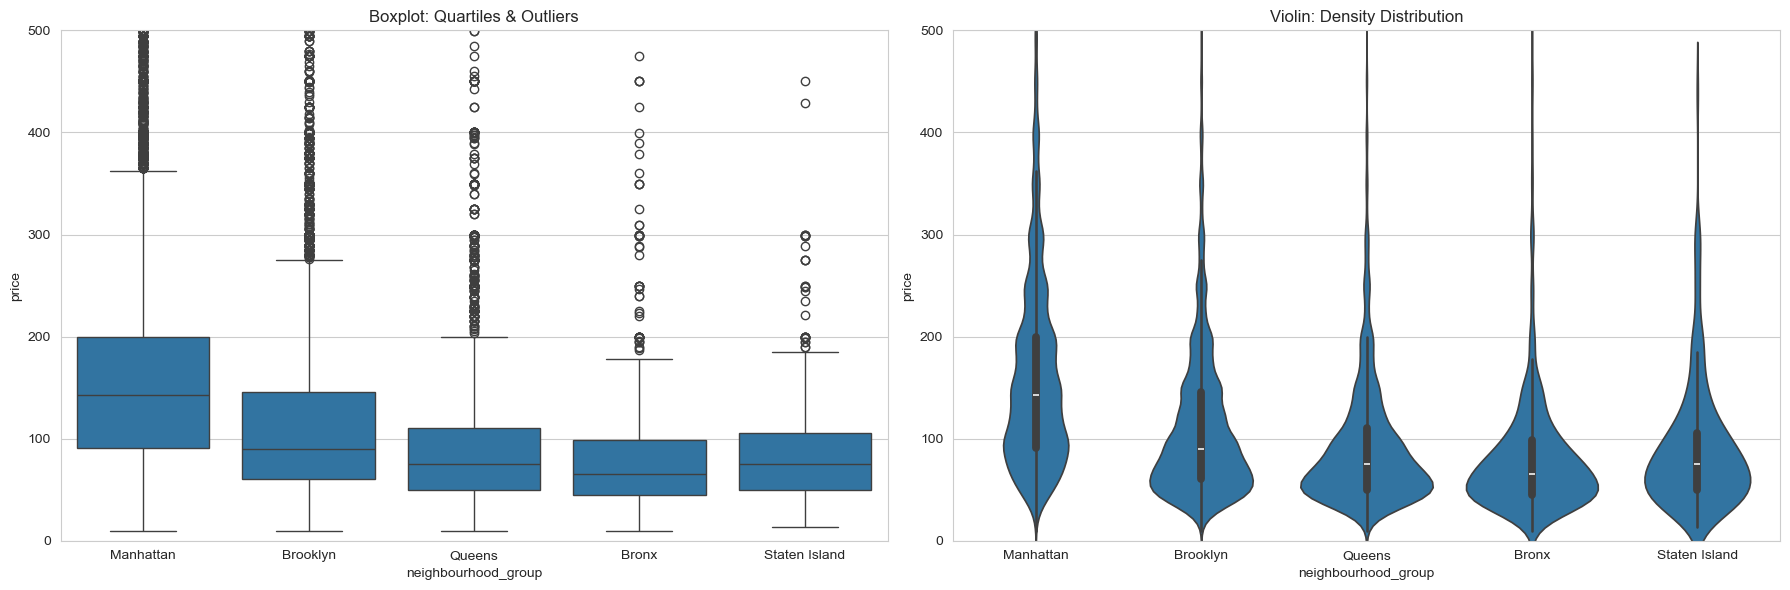

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

order = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
data_filtered = df[df['price'] < 500]

sns.boxplot(data=data_filtered, x='neighbourhood_group', y='price', 
            order=order, ax=axes[0])
axes[0].set_title('Boxplot: Quartiles & Outliers')
axes[0].set_ylim(0, 500)

sns.violinplot(data=data_filtered, x='neighbourhood_group', y='price', 
               order=order, ax=axes[1])
axes[1].set_title('Violin: Density Distribution')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

In [18]:
df.groupby('neighbourhood_group')['price'].agg(['mean', 'median', 'count']).round(2)

,mean,median,count
neighbourhood_group,,,
Bronx,87.58,65.0,1090
Brooklyn,124.45,90.0,20089
Manhattan,196.89,150.0,21654
Queens,99.49,75.0,5664
Staten Island,114.81,75.0,373


### Explanation for Boxplot and Violin Plot

The boxplot shows that Manhattan has the highest median nightly price and the widest price dispersion among all boroughs. Manhattan and Brooklyn also show many high-price outliers, indicating a long tail of premium or luxury listings.

The violin plot reveals that all boroughs are right-skewed, with most listings concentrated in the lower-to-mid price range. Manhattan stands out with a thicker mid-to-high-price segment, while Brooklyn, Queens, and Bronx are more concentrated at lower prices.

For readability, this visualization limits the y-axis to listings below $500. This does not remove high-price listings from the dataset; it only makes the main distribution easier to compare.

### A2: Nightly Price Outlier Detection

In [19]:
# use IQR method to detect abnormal price
def detect_outliers(group):
    Q1 = group['price'].quantile(0.25)
    Q3 = group['price'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3+1.5*IQR
    return pd.Series({
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'upper_bound': upper_bound,
        'outlier_count': (group['price']>upper_bound).sum(),
        'outlier_pct': (group['price'] > upper_bound).sum() / len(group) * 100
    })
outlier_stats = df.groupby('neighbourhood_group').apply(detect_outliers).round(2)
print(outlier_stats)


                       Q1     Q3    IQR  upper_bound  outlier_count  \
neighbourhood_group                                                   
Bronx                45.0   99.0   54.0        180.0           61.0   
Brooklyn             60.0  150.0   90.0        285.0          996.0   
Manhattan            95.0  220.0  125.0        407.5         1289.0   
Queens               50.0  110.0   60.0        200.0          322.0   
Staten Island        50.0  110.0   60.0        200.0           25.0   

                     outlier_pct  
neighbourhood_group               
Bronx                       5.60  
Brooklyn                    4.96  
Manhattan                   5.95  
Queens                      5.69  
Staten Island               6.70  


C:\Users\liyua\AppData\Local\Temp\ipykernel_76084\1180959355.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_stats = df.groupby('neighbourhood_group').apply(detect_outliers).round(2)


The IQR method identifies unusually expensive listings within each borough. Manhattan and Brooklyn contain the largest number of price outliers, which is expected because they have larger listing volume and stronger demand. The outlier percentage is also important because it shows how common premium listings are relative to borough size.

These outliers suggest that high-end pricing opportunities exist across boroughs, but average price can be strongly distorted by extreme luxury listings. For pricing strategy, median price, IQR, and 90th percentile price are more reliable than mean price alone.

### A3: Median Nightly Price Matrix by Borough and Room Type

This section compares median nightly prices across borough and room type combinations. Median price is used instead of average price because Airbnb prices are highly right-skewed and contain extreme outliers.


In [20]:
price_data = df[df['price'] > 0]

price_matrix = pd.pivot_table(
    price_data,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
)

price_matrix.round(2)


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,54.0,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


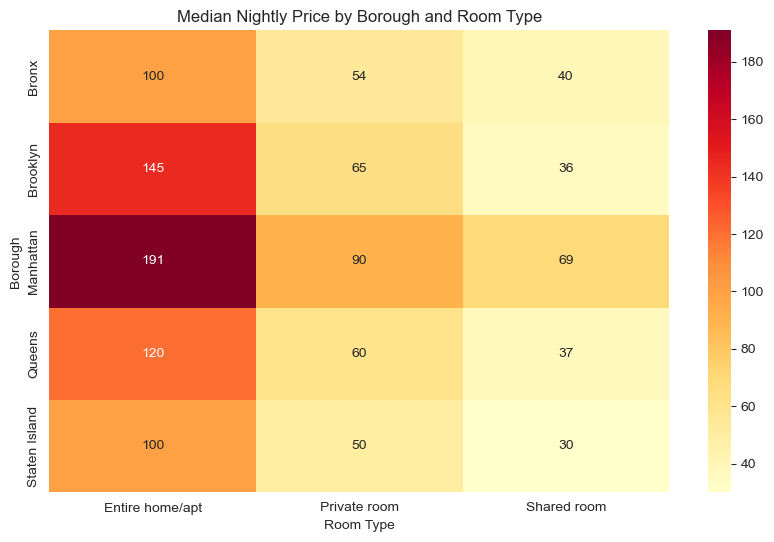

In [21]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    price_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Median Nightly Price by Borough and Room Type')
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.show()


### Explanation for A3: Median Price Matrix

The matrix compares typical nightly price levels for each borough and room type combination. The result shows that `Entire home/apt` is consistently the highest-priced room type across boroughs, while private rooms and shared rooms are more affordable.

Manhattan has the highest median price levels, especially for entire homes. Brooklyn is also an important mid-to-high-price market, while Queens, Bronx, and Staten Island generally have lower median prices. This supports the pricing insight that full-unit listings in Manhattan and selected Brooklyn areas represent premium listing segments, but this should be interpreted as pricing power rather than confirmed profit.


### A4: Top Reliable Neighbourhoods by Median Nightly Price

This section identifies neighbourhoods with the highest typical nightly prices. To avoid unstable conclusions from very small samples, neighbourhoods with fewer than 30 listings are excluded from the final ranking.


In [22]:
neighbourhood_price = (
    price_data
    .groupby('neighbourhood')
    .agg(
        median_price=('price', 'median'),
        avg_price=('price', 'mean'),
        p90_price=('price', lambda x: x.quantile(0.90)),
        price_iqr=('price', lambda x: x.quantile(0.75) - x.quantile(0.25)),
        listing_count=('id', 'count')
    )
    .sort_values('median_price', ascending=False)
)

neighbourhood_price.head(10).round(2)


,median_price,avg_price,p90_price,price_iqr,listing_count
neighbourhood,,,,,
Fort Wadsworth,800.0,800.00,800.0,0.00,1
Woodrow,700.0,700.00,700.0,0.00,1
Tribeca,295.0,490.64,867.6,285.00,177
Neponsit,274.0,274.67,334.8,75.00,3
NoHo,250.0,295.72,496.2,170.75,78
Willowbrook,249.0,249.00,249.0,0.00,1
Flatiron District,225.0,341.92,600.0,220.00,80
Midtown,210.0,282.74,550.0,195.50,1544
West Village,200.0,267.68,400.0,121.50,768


The first ranking can still include neighbourhoods with very small sample sizes. These results are useful for data quality checking, but they should not be used directly for business conclusions.


In [23]:
top_neighbourhoods_reliable = (
    neighbourhood_price[neighbourhood_price['listing_count'] >= 30]
    .sort_values('median_price', ascending=False)
)

top_neighbourhoods_reliable.head(10).round(2)


,median_price,avg_price,p90_price,price_iqr,listing_count
neighbourhood,,,,,
Tribeca,295.0,490.64,867.6,285.00,177
NoHo,250.0,295.72,496.2,170.75,78
Flatiron District,225.0,341.92,600.0,220.00,80
Midtown,210.0,282.74,550.0,195.50,1544
West Village,200.0,267.68,400.0,121.50,768
Financial District,200.0,225.49,389.4,103.00,744
SoHo,199.0,287.10,595.0,216.25,358
Chelsea,199.0,249.74,389.0,140.00,1113
Greenwich Village,198.5,264.01,395.5,110.00,390


After applying the sample-size filter, the ranking gives a more stable view of high-price neighbourhoods. This step keeps the analysis from being driven by one or two unusual luxury listings.


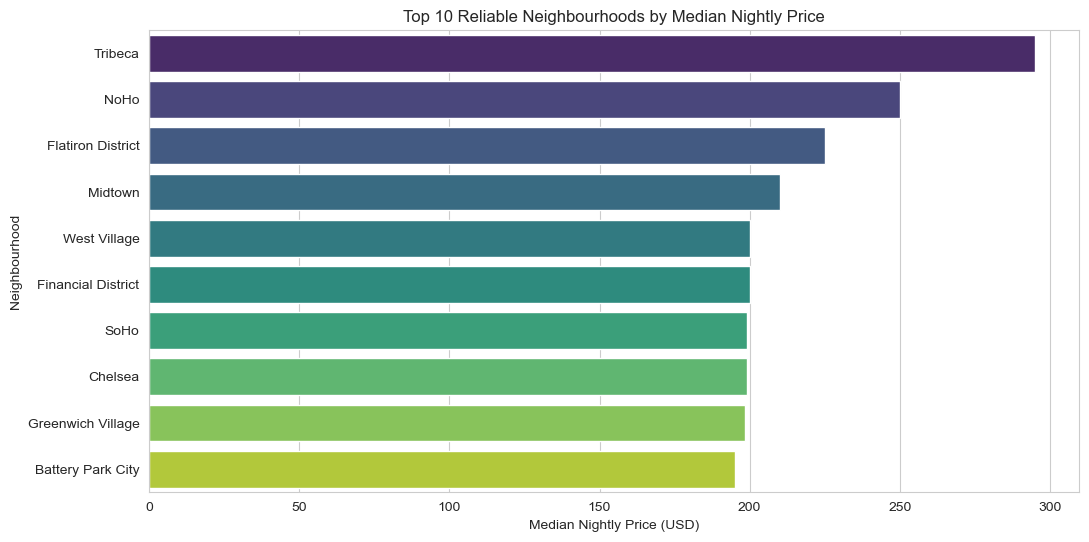

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_neighbourhoods_reliable.head(10).reset_index(),
    x='median_price',
    y='neighbourhood',
    hue='neighbourhood',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Reliable Neighbourhoods by Median Nightly Price')
plt.xlabel('Median Nightly Price (USD)')
plt.ylabel('Neighbourhood')
plt.show()


### Explanation for A4: Top Reliable Neighbourhoods

This analysis identifies high-price neighbourhoods after filtering out neighbourhoods with fewer than 30 listings. The sample-size filter is important because small neighbourhood samples can produce unstable rankings.

The reliable high-price neighbourhoods are mainly concentrated in Manhattan, with selected nearby Brooklyn areas also appearing in the upper tier. These neighbourhoods represent strong pricing-power markets. However, this result should not be described as profit performance because the dataset does not contain confirmed bookings, costs, fees, or taxes.


### A5: Geographic Distribution of Nightly Price

This section maps listing-level nightly prices across NYC. The color scale is capped at the 95th percentile to reduce the visual distortion caused by extreme luxury listings.


In [25]:
price_map_data = df[df['price'] > 0]
price_vmax = price_map_data['price'].quantile(0.95)

from PIL import Image
import numpy as np

nyc_image = np.array(Image.open('New_York_City_.png'))


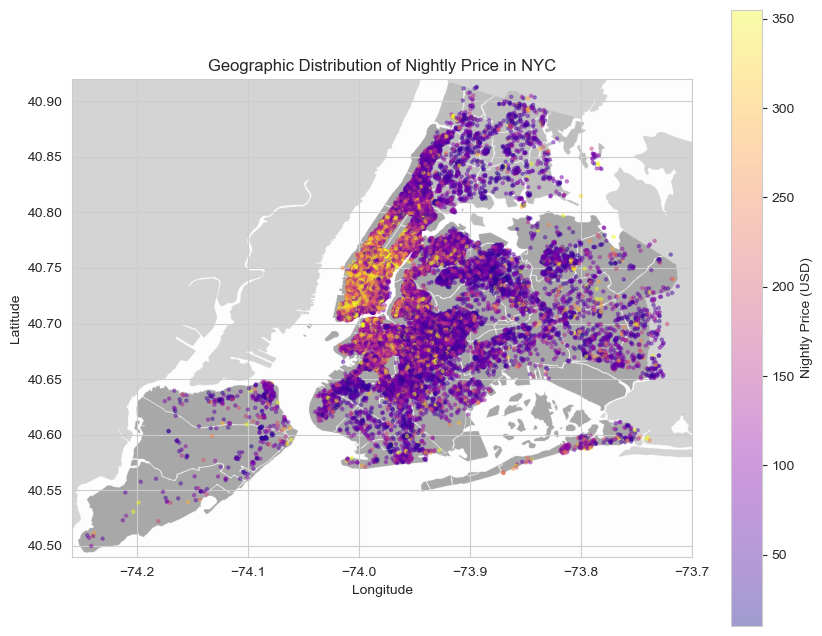

In [26]:
plt.figure(figsize=(10, 8))

plt.imshow(
    nyc_image,
    zorder=0,
    extent=[-74.258, -73.7, 40.49, 40.92],
    alpha=0.6
)

scatter = plt.scatter(
    price_map_data['longitude'],
    price_map_data['latitude'],
    c=price_map_data['price'],
    cmap='plasma',
    alpha=0.4,
    s=5,
    vmax=price_vmax
)

plt.colorbar(scatter, label='Nightly Price (USD)')

plt.title('Geographic Distribution of Nightly Price in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


### Explanation for A5: Geographic Distribution of Nightly Price

This map visualizes the spatial distribution of nightly prices across NYC Airbnb listings. Each point represents one listing, and the color represents nightly price. The 95th percentile cap makes the general spatial pattern easier to interpret without allowing a few extreme listings to dominate the color scale.

The map shows that higher-price listings are concentrated mainly in Manhattan, especially central and lower Manhattan. Parts of northern and western Brooklyn also show moderate-to-high prices, while Queens, Bronx, and Staten Island generally contain more lower-price listings.

This spatial pattern supports the earlier pricing findings from A3 and A4: pricing power is concentrated in Manhattan and selected nearby Brooklyn neighbourhoods.


----
## Part B: Demand Proxy and Recommendation Insights

Because the dataset does not include direct guest rating or satisfaction scores, this section uses review-related variables as proxies for demand and guest interest. `reviews_per_month` is treated as a demand proxy, while `number_of_reviews` is used to filter for listings with enough review history.

These metrics do not measure true satisfaction. They only indicate review activity and market attention.


### B1: Review Activity by Room Type

To avoid unreliable results from listings with very few reviews, this analysis only includes listings with at least 5 reviews. This means the analysis focuses on mature listings with some review history, not brand-new listings.


In [27]:
review_data = df[df['number_of_reviews'] >= 5]


In [28]:
room_popularity = (
    review_data
    .groupby('room_type')
    .agg(
        avg_reviews=('number_of_reviews', 'mean'),
        median_reviews=('number_of_reviews', 'median'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        listing_count=('id', 'count')
    )
    .sort_values('avg_reviews_per_month', ascending=False)
)

room_popularity.round(2)


,avg_reviews,median_reviews,avg_reviews_per_month,listing_count
room_type,,,,
Private room,45.50,23.0,1.99,11549
Shared room,34.54,18.0,1.95,540
Entire home/apt,41.84,21.0,1.73,13520


### Explanation for B1: Review Activity by Room Type

The results show that `Private room` has the highest review activity, including average reviews, median reviews, and average reviews per month. This suggests that private rooms receive strong guest engagement among mature listings.

This contrasts with the pricing analysis: `Entire home/apt` listings are typically priced higher, but private rooms show stronger review activity. For homepage recommendations, this means Airbnb should not only promote premium entire homes. Popular and frequently reviewed private rooms may improve user relevance, affordability, and trust.


### B2: Relationship Between Price and Review Activity

This section examines whether higher price is associated with stronger or weaker review activity. The relationship is descriptive only and should not be interpreted as causal because borough, room type, listing age, and other factors may also affect reviews.


In [29]:
price_review_corr = review_data[
    ['price', 'number_of_reviews', 'reviews_per_month']
].corr()

price_review_corr.round(2)


,price,number_of_reviews,reviews_per_month
price,1.00,-0.04,-0.05
number_of_reviews,-0.04,1.00,0.48
reviews_per_month,-0.05,0.48,1.00


### Explanation for B2: Price and Review Activity

The correlation between price and number of reviews is very close to zero, and the correlation between price and reviews per month is also very close to zero. This means there is little unconditional correlation between nightly price and review activity.

This does not prove that price has no effect on guest interest. It only shows that, in this dataset without controlling for borough, room type, listing age, and other factors, expensive listings do not automatically show stronger review activity.


### B3: High-Price and High-Demand Neighbourhoods

This section identifies neighbourhoods that combine above-median nightly price with above-median review activity. Median nightly price represents pricing power, while average reviews per month is used as a demand proxy.


In [30]:
neighbourhood_demand = (
    review_data
    .groupby('neighbourhood')
    .agg(
        borough=('neighbourhood_group', lambda x: x.mode().iloc[0]),
        median_price=('price', 'median'),
        p90_price=('price', lambda x: x.quantile(0.90)),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews=('number_of_reviews', 'median'),
        listing_count=('id', 'count')
    )
)

neighbourhood_strategy = neighbourhood_demand[
    neighbourhood_demand['listing_count'] >= 30
]

neighbourhood_strategy.sort_values(
    ['median_price', 'avg_reviews_per_month'],
    ascending=False
).head(10).round(2)


,borough,median_price,p90_price,avg_reviews_per_month,median_reviews,listing_count
neighbourhood,,,,,,
Tribeca,Manhattan,275.0,700.0,1.24,15.0,63
NoHo,Manhattan,252.5,517.2,1.08,20.0,34
Flatiron District,Manhattan,245.5,600.0,1.64,20.0,34
Financial District,Manhattan,225.0,425.0,2.10,10.0,280
West Village,Manhattan,200.0,375.0,1.20,17.0,400
Greenwich Village,Manhattan,199.0,350.0,1.29,18.0,190
SoHo,Manhattan,195.0,550.0,1.53,20.0,185
Midtown,Manhattan,185.0,399.0,1.91,15.0,538
Chelsea,Manhattan,180.0,390.0,1.74,23.0,501


The table above ranks reliable neighbourhoods by median price and then review activity. This helps identify premium neighbourhoods with enough sample size, but it still prioritizes price first.


In [31]:
price_threshold = neighbourhood_strategy['median_price'].median()
demand_threshold = neighbourhood_strategy['avg_reviews_per_month'].median()

high_price_high_demand_neighbourhoods = neighbourhood_strategy[
    (neighbourhood_strategy['median_price'] >= price_threshold) &
    (neighbourhood_strategy['avg_reviews_per_month'] >= demand_threshold)
].sort_values(
    ['median_price', 'avg_reviews_per_month'],
    ascending=False
)

high_price_high_demand_neighbourhoods.head(10).round(2)


,borough,median_price,p90_price,avg_reviews_per_month,median_reviews,listing_count
neighbourhood,,,,,,
Financial District,Manhattan,225.0,425.0,2.10,10.0,280
Midtown,Manhattan,185.0,399.0,1.91,15.0,538
Theater District,Manhattan,172.0,365.0,3.70,17.0,88
Hell's Kitchen,Manhattan,150.0,300.0,2.41,22.0,1026
Gowanus,Brooklyn,139.0,299.7,1.87,23.5,144
Arverne,Queens,125.0,295.0,1.93,28.0,53
Rockaway Beach,Queens,120.0,191.6,1.94,29.0,35
Two Bridges,Manhattan,100.0,188.0,3.20,28.0,43
East Harlem,Manhattan,100.0,200.0,2.09,29.0,688


### Explanation for B3: High-Price and High-Demand Neighbourhoods

Instead of ranking neighbourhoods only by price, this step filters for neighbourhoods whose median nightly price and average reviews per month are both above the median level. This identifies areas that combine pricing power with stronger review activity.

These neighbourhoods are useful for homepage recommendation strategy because they are not only premium markets, but also show evidence of guest attention. This creates a more balanced recommendation logic than simply promoting the most expensive listings.


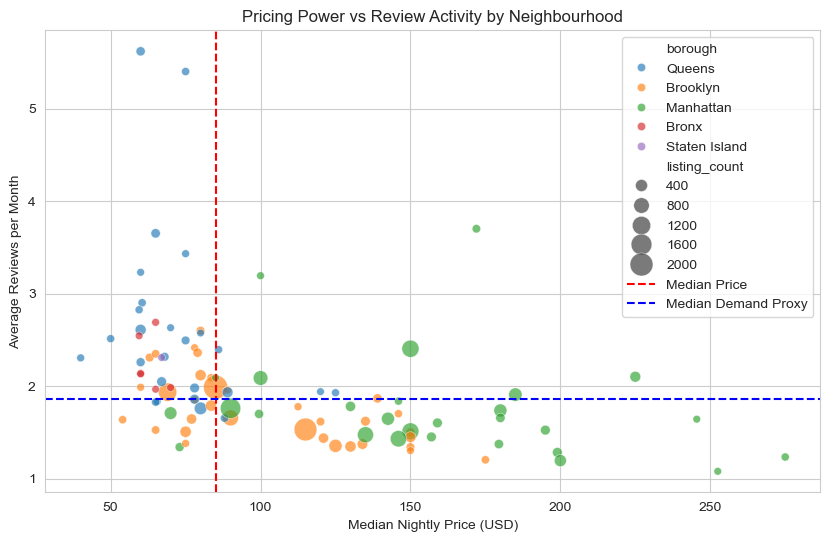

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=neighbourhood_strategy,
    x='median_price',
    y='avg_reviews_per_month',
    size='listing_count',
    hue='borough',
    sizes=(30, 300),
    alpha=0.65
)

plt.axvline(
    price_threshold,
    color='red',
    linestyle='--',
    label='Median Price'
)

plt.axhline(
    demand_threshold,
    color='blue',
    linestyle='--',
    label='Median Demand Proxy'
)

plt.title('Pricing Power vs Review Activity by Neighbourhood')
plt.xlabel('Median Nightly Price (USD)')
plt.ylabel('Average Reviews per Month')
plt.legend()
plt.show()


### Explanation for B3 Scatter Plot

This scatter plot compares neighbourhood-level pricing power and review activity. Each point represents one neighbourhood. The x-axis shows median nightly price, and the y-axis shows average reviews per month. Point size represents listing count, so larger points indicate more reliable neighbourhood-level patterns.

The red dashed line marks the median neighbourhood price, and the blue dashed line marks the median review activity level. Neighbourhoods in the upper-right quadrant are the strongest candidates for homepage recommendation because they combine above-median price with above-median demand proxy.

The chart shows that high price and high review activity do not always appear together. Some expensive neighbourhoods have lower review activity, while some highly reviewed neighbourhoods are more affordable. This supports a balanced recommendation strategy rather than a price-only strategy.


## Conclusion

This project analyzes the NYC Airbnb 2019 dataset as a historical pricing and demand case study. The final analysis avoids treating `365 - availability_365` as booked nights because future unavailable calendar days are not the same as confirmed historical reservations. As a result, the project focuses on defensible listing-level metrics such as nightly price, listing count, future availability, and review activity.

The pricing analysis shows that Manhattan is the strongest high-price market, followed by selected areas in Brooklyn. `Entire home/apt` listings consistently have higher median nightly prices than private rooms and shared rooms, especially in Manhattan. At the neighbourhood level, reliable high-price areas are concentrated mainly in Manhattan after filtering out small-sample neighbourhoods. The geographic price map also shows that high-price listings are spatially concentrated in Manhattan and nearby Brooklyn areas.

The demand-proxy analysis shows a different pattern. Since the dataset does not include direct guest satisfaction scores, review activity is used only as a proxy for guest interest. Private rooms show stronger review activity than entire homes among listings with at least 5 reviews. The price-review correlation is close to zero, meaning there is little unconditional relationship between nightly price and review activity. This does not prove causality, but it does show that expensive listings are not automatically the most review-active.

Overall, Airbnb's dashboard and recommendation strategy should balance pricing power, review activity, affordability, and sample reliability. Premium entire homes in Manhattan and parts of Brooklyn are important high-price segments, but homepage recommendations should also include frequently reviewed private rooms and neighbourhoods with strong demand signals. This creates a more credible recommendation strategy than simply promoting the most expensive listings.
